In [1]:
!pip install shap lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=d5f7e41d1032e9787df43a4e40848f67cb6a4d541de66662d5b8c6d959e3aa57
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import shap
from lime.lime_tabular import LimeTabularExplainer

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
import pandas as pd

movies = pd.read_csv("tmdb_5000_movies.csv")
credits = pd.read_csv("tmdb_5000_credits.csv")

print("Movies dataset shape:", movies.shape)
print("Credits dataset shape:", credits.shape)

Movies dataset shape: (4803, 20)
Credits dataset shape: (4803, 4)


In [4]:
print("MOVIES DATASET")
display(movies.head())

print("\nCREDITS DATASET")
display(credits.head())

MOVIES DATASET


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124



CREDITS DATASET


,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [5]:
print("Movies columns:")
print(movies.columns.tolist())

print("\nCredits columns:")
print(credits.columns.tolist())

Movies columns:
['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count']

Credits columns:
['movie_id', 'title', 'cast', 'crew']


In [6]:
# Merge movies and credits datasets

movies = movies.merge(
    credits,
    left_on="id",
    right_on="movie_id"
)

print("Merged dataset shape:", movies.shape)

Merged dataset shape: (4803, 24)


In [7]:
# Select useful columns

movies = movies[
    [
        "title_x",
        "genres",
        "keywords",
        "cast",
        "crew",
        "overview"
    ]
]

# Rename title column
movies.rename(columns={"title_x": "title"}, inplace=True)

print(movies.columns.tolist())

['title', 'genres', 'keywords', 'cast', 'crew', 'overview']


In [8]:
# Check missing values

print(movies.isnull().sum())

title       0
genres      0
keywords    0
cast        0
crew        0
overview    3
dtype: int64


In [9]:
# Replace missing values with empty text

movies = movies.fillna("")

print("Missing values after cleaning:")
print(movies.isnull().sum())

Missing values after cleaning:
title       0
genres      0
keywords    0
cast        0
crew        0
overview    0
dtype: int64


In [10]:
# Combine important movie information

movies["combined_features"] = (
    movies["genres"] + " " +
    movies["keywords"] + " " +
    movies["cast"] + " " +
    movies["crew"] + " " +
    movies["overview"]
)

print(movies[["title", "combined_features"]].head())


                                      title  \
0                                    Avatar   
1  Pirates of the Caribbean: At World's End   
2                                   Spectre   
3                     The Dark Knight Rises   
4                               John Carter   

                                   combined_features  
0  [{"id": 28, "name": "Action"}, {"id": 12, "nam...  
1  [{"id": 12, "name": "Adventure"}, {"id": 14, "...  
2  [{"id": 28, "name": "Action"}, {"id": 12, "nam...  
3  [{"id": 28, "name": "Action"}, {"id": 80, "nam...  
4  [{"id": 28, "name": "Action"}, {"id": 12, "nam...  


In [11]:
import ast

# Convert JSON-like text into useful names
def get_names(text):
    try:
        data = ast.literal_eval(text)
        return [item["name"].replace(" ", "").lower() for item in data]
    except:
        return []

# Extract director from crew
def get_director(text):
    try:
        data = ast.literal_eval(text)
        for item in data:
            if item["job"] == "Director":
                return item["name"].replace(" ", "").lower()
        return ""
    except:
        return ""

# Clean genres
movies["genres"] = movies["genres"].apply(get_names)

# Clean keywords
movies["keywords"] = movies["keywords"].apply(get_names)

# Keep only top 5 cast members
movies["cast"] = movies["cast"].apply(
    lambda x: get_names(x)[:5]
)

# Extract director
movies["director"] = movies["crew"].apply(get_director)

# Clean overview
movies["overview"] = movies["overview"].apply(
    lambda x: str(x).lower().replace(" ", "")
)

print("Data cleaning completed!")

Data cleaning completed!


In [12]:
display(
    movies[
        ["title", "genres", "keywords", "cast", "director", "overview"]
    ].head()
)

,title,genres,keywords,cast,director,overview
0,Avatar,"[action, adventure, fantasy, sciencefiction]","[cultureclash, future, spacewar, spacecolony, ...","[samworthington, zoesaldana, sigourneyweaver, ...",jamescameron,"inthe22ndcentury,aparaplegicmarineisdispatched..."
1,Pirates of the Caribbean: At World's End,"[adventure, fantasy, action]","[ocean, drugabuse, exoticisland, eastindiatrad...","[johnnydepp, orlandobloom, keiraknightley, ste...",goreverbinski,"captainbarbossa,longbelievedtobedead,hascomeba..."
2,Spectre,"[action, adventure, crime]","[spy, basedonnovel, secretagent, sequel, mi6, ...","[danielcraig, christophwaltz, léaseydoux, ralp...",sammendes,acrypticmessagefrombond’spastsendshimonatrailt...
3,The Dark Knight Rises,"[action, crime, drama, thriller]","[dccomics, crimefighter, terrorist, secretiden...","[christianbale, michaelcaine, garyoldman, anne...",christophernolan,"followingthedeathofdistrictattorneyharveydent,..."
4,John Carter,"[action, adventure, sciencefiction]","[basedonnovel, mars, medallion, spacetravel, p...","[taylorkitsch, lynncollins, samanthamorton, wi...",andrewstanton,"johncarterisawar-weary,formermilitarycaptainwh..."


In [13]:
movies["combined_features"] = (
    movies["genres"].apply(lambda x: " ".join(x)) + " " +
    movies["keywords"].apply(lambda x: " ".join(x)) + " " +
    movies["cast"].apply(lambda x: " ".join(x)) + " " +
    movies["director"] + " " +
    movies["overview"]
)

print(movies[["title", "combined_features"]].head())

                                      title  \
0                                    Avatar   
1  Pirates of the Caribbean: At World's End   
2                                   Spectre   
3                     The Dark Knight Rises   
4                               John Carter   

                                   combined_features  
0  action adventure fantasy sciencefiction cultur...  
1  adventure fantasy action ocean drugabuse exoti...  
2  action adventure crime spy basedonnovel secret...  
3  action crime drama thriller dccomics crimefigh...  
4  action adventure sciencefiction basedonnovel m...  


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

# Convert combined movie features into numerical vectors
tfidf_matrix = tfidf.fit_transform(
    movies["combined_features"]
)

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (4803, 5000)


In [15]:
from sklearn.metrics.pairwise import cosine_similarity

# Calculate similarity between all movies
similarity = cosine_similarity(tfidf_matrix)

print("Similarity matrix shape:", similarity.shape)

Similarity matrix shape: (4803, 4803)


In [16]:
# Create movie title index

movie_indices = pd.Series(
    movies.index,
    index=movies["title"]
).drop_duplicates()

print(movie_indices.head())

title
Avatar                                      0
Pirates of the Caribbean: At World's End    1
Spectre                                     2
The Dark Knight Rises                       3
John Carter                                 4
dtype: int64


In [18]:
def recommend_movies(movie_title, num_recommendations=5):

    # Check whether movie exists
    if movie_title not in movie_indices:
        print("Movie not found. Please check the movie title.")
        return

    # Get movie index
    idx = movie_indices[movie_title]

    # Get similarity scores
    similarity_scores = list(
        enumerate(similarity[idx])
    )

    # Sort by similarity
    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    # Remove the selected movie itself
    similarity_scores = similarity_scores[1:num_recommendations + 1]

    print(f"\nBecause you liked: {movie_title}")
    print("\nRecommended Movies:\n")

    for i, score in similarity_scores:
        print(
            f"{movies.iloc[i]['title']} "
            f"→ Similarity: {score:.3f}"
        )

In [19]:
recommend_movies("Avatar")


Because you liked: Avatar

Recommended Movies:

Star Trek Into Darkness → Similarity: 0.243
Aliens → Similarity: 0.241
Cargo → Similarity: 0.200
Alien³ → Similarity: 0.173
A Monster in Paris → Similarity: 0.171


In [20]:
# Select movie to explain

movie_name = "Avatar"

movie_index = movie_indices[movie_name]

print("Selected movie:", movie_name)
print("Movie index:", movie_index)

Selected movie: Avatar
Movie index: 0


In [21]:
# Get TF-IDF vector for the selected movie

movie_vector = tfidf_matrix[movie_index].toarray()[0]

# Get feature names
feature_names = tfidf.get_feature_names_out()

# Find features with highest TF-IDF values
top_indices = movie_vector.argsort()[-20:][::-1]

top_features = feature_names[top_indices]
top_values = movie_vector[top_indices]

print("Top features for", movie_name)

for feature, value in zip(top_features, top_values):
    print(f"{feature}: {value:.4f}")

Top features for Avatar
loveaffair: 0.2405
tribe: 0.2339
mindandsoul: 0.2284
cgi: 0.2284
stephenlang: 0.2239
spacecolony: 0.2239
society: 0.2239
jamescameron: 0.2199
alienplanet: 0.2199
samworthington: 0.2164
futuristic: 0.2133
marine: 0.2133
michellerodriguez: 0.2104
cultureclash: 0.2012
zoesaldana: 0.1993
sigourneyweaver: 0.1885
spacetravel: 0.1885
space: 0.1816
battle: 0.1787
soldier: 0.1692


In [22]:
# Use the top features for XAI explanation

explain_features = list(top_features[:15])

# Get their column positions
feature_indices = [
    np.where(feature_names == feature)[0][0]
    for feature in explain_features
]

print("Features used for explanation:")
print(explain_features)

Features used for explanation:
['loveaffair', 'tribe', 'mindandsoul', 'cgi', 'stephenlang', 'spacecolony', 'society', 'jamescameron', 'alienplanet', 'samworthington', 'futuristic', 'marine', 'michellerodriguez', 'cultureclash', 'zoesaldana']


In [23]:
# Target movie vector
target_vector = tfidf_matrix[movie_index].toarray()[0]

def explanation_model(X):
    """
    Calculates similarity between the target movie
    and modified feature vectors.
    """

    results = []

    for row in X:

        # Start with the target movie vector
        modified_vector = target_vector.copy()

        # Turn selected features on/off
        for j, feature_index in enumerate(feature_indices):
            modified_vector[feature_index] *= row[j]

        # Calculate similarity
        score = cosine_similarity(
            [target_vector],
            [modified_vector]
        )[0][0]

        results.append(score)

    return np.array(results)

In [24]:
import shap

# Background data
background = np.ones((10, len(explain_features)))

# SHAP explainer
explainer = shap.KernelExplainer(
    explanation_model,
    background
)

# Explain the original movie
instance = np.ones((1, len(explain_features)))

shap_values = explainer.shap_values(
    instance,
    nsamples=100
)

print("SHAP explanation generated successfully!")

  0%|          | 0/1 [00:00<?, ?it/s]

SHAP explanation generated successfully!


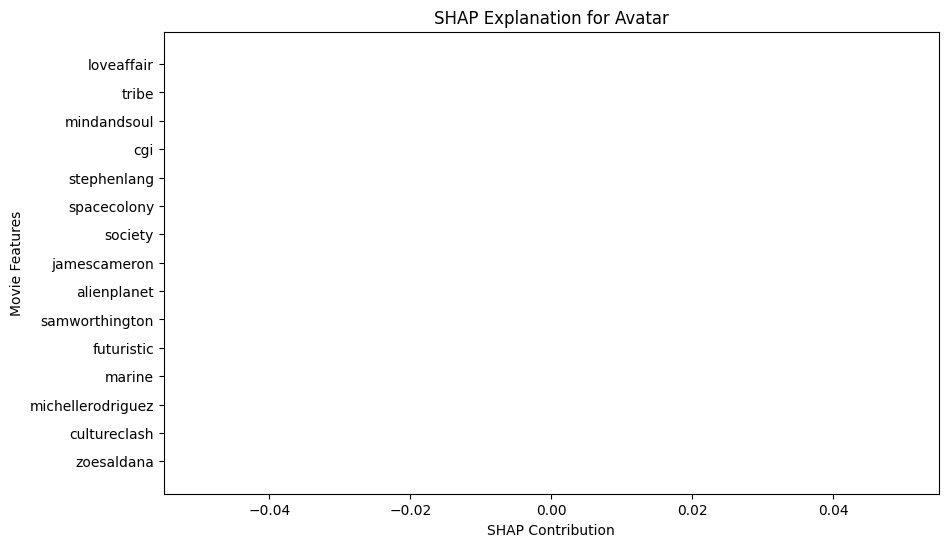

In [25]:
# Convert SHAP output into an array

if isinstance(shap_values, list):
    shap_values_plot = shap_values[0]
else:
    shap_values_plot = shap_values

shap_values_plot = np.array(shap_values_plot)

if shap_values_plot.ndim > 1:
    shap_values_plot = shap_values_plot[0]

# SHAP bar chart
plt.figure(figsize=(10, 6))

plt.barh(
    explain_features,
    shap_values_plot
)

plt.xlabel("SHAP Contribution")
plt.ylabel("Movie Features")
plt.title("SHAP Explanation for Avatar")

plt.gca().invert_yaxis()
plt.show()

In [26]:
from lime.lime_tabular import LimeTabularExplainer

# Create training data for LIME
lime_training_data = np.random.randint(
    0,
    2,
    size=(100, len(explain_features))
)

# Create LIME explainer
lime_explainer = LimeTabularExplainer(
    lime_training_data,
    feature_names=explain_features,
    mode="regression",
    discretize_continuous=False
)

print("LIME explainer created successfully!")

LIME explainer created successfully!


In [27]:
# Explain Avatar

lime_exp = lime_explainer.explain_instance(
    instance[0],
    explanation_model,
    num_features=10
)

print("LIME explanation:")
for feature, weight in lime_exp.as_list():
    print(f"{feature}: {weight:.4f}")

LIME explanation:
loveaffair: 0.0175
tribe: 0.0168
marine: 0.0151
mindandsoul: 0.0146
society: 0.0140
alienplanet: 0.0138
jamescameron: 0.0137
stephenlang: 0.0132
spacecolony: 0.0131
futuristic: 0.0131


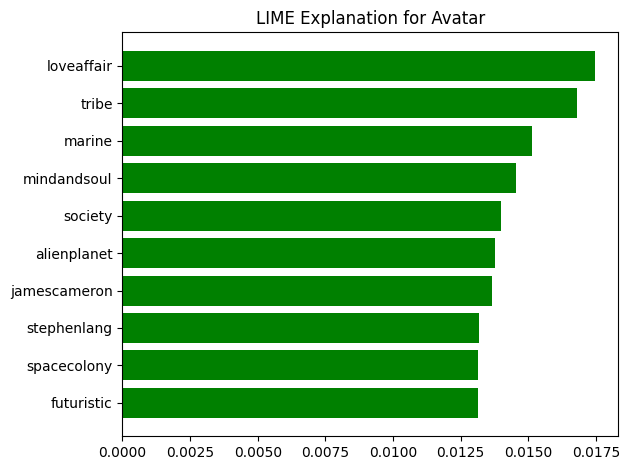

In [28]:
lime_exp.as_pyplot_figure()

plt.title("LIME Explanation for Avatar")
plt.tight_layout()
plt.show()

In [29]:
def get_recommendations(movie_title, num_recommendations=5):

    if movie_title not in movie_indices:
        print("Movie not found.")
        return None

    idx = movie_indices[movie_title]

    scores = list(enumerate(similarity[idx]))

    scores = sorted(
        scores,
        key=lambda x: x[1],
        reverse=True
    )

    scores = scores[1:num_recommendations + 1]

    results = []

    for movie_idx, score in scores:
        results.append({
            "Recommended Movie": movies.iloc[movie_idx]["title"],
            "Similarity Score": round(score, 4)
        })

    return pd.DataFrame(results)

In [30]:
recommendation_table = get_recommendations("Avatar", 5)

display(recommendation_table)

,Recommended Movie,Similarity Score
0,Star Trek Into Darkness,0.2426
1,Aliens,0.2408
2,Cargo,0.2001
3,Alien³,0.1734
4,A Monster in Paris,0.1707


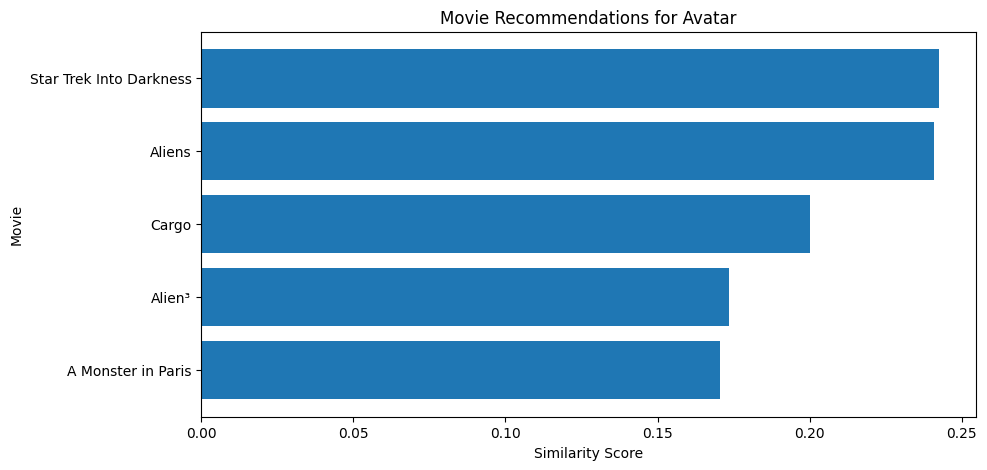

In [31]:
plt.figure(figsize=(10, 5))

plt.barh(
    recommendation_table["Recommended Movie"],
    recommendation_table["Similarity Score"]
)

plt.xlabel("Similarity Score")
plt.ylabel("Movie")
plt.title("Movie Recommendations for Avatar")

plt.gca().invert_yaxis()
plt.show()

In [32]:
recommended_movie = recommendation_table.iloc[0]["Recommended Movie"]

print("Selected movie:", "Avatar")
print("Recommended movie:", recommended_movie)

Selected movie: Avatar
Recommended movie: Star Trek Into Darkness


In [33]:
def get_feature_words(movie_title):

    idx = movie_indices[movie_title]

    vector = tfidf_matrix[idx].toarray()[0]

    feature_names = tfidf.get_feature_names_out()

    indices = vector.argsort()[-30:][::-1]

    return set(feature_names[indices])

In [34]:
selected_features = get_feature_words("Avatar")
recommended_features = get_feature_words(recommended_movie)

common_features = selected_features.intersection(
    recommended_features
)

print("Common important features:")
print(common_features)

Common important features:
{'adventure', 'filmmaking', 'futuristic', '3d', 'action', 'alien', 'zoesaldana', 'space', 'sciencefiction'}


In [35]:
print("=" * 60)
print("EXPLAINABLE MOVIE RECOMMENDATION")
print("=" * 60)

print("\nUser liked:")
print("🎬 Avatar")

print("\nRecommended:")
print("🎬", recommended_movie)

print("\nSimilarity Score:")
print(round(
    recommendation_table.iloc[0]["Similarity Score"],
    4
))

print("\nWhy was this movie recommended?")

for feature in list(common_features)[:10]:
    print("✓", feature)

EXPLAINABLE MOVIE RECOMMENDATION

User liked:
🎬 Avatar

Recommended:
🎬 Star Trek Into Darkness

Similarity Score:
0.2426

Why was this movie recommended?
✓ adventure
✓ filmmaking
✓ futuristic
✓ 3d
✓ action
✓ alien
✓ zoesaldana
✓ space
✓ sciencefiction


In [36]:
print("=" * 60)
print("XAI METHODS USED")
print("=" * 60)

print("""
SHAP:
Explains the contribution of individual movie features
to the recommendation.

LIME:
Explains the important features for this specific
movie recommendation.

Together, SHAP and LIME make the recommendation
system more transparent and understandable.
""")

XAI METHODS USED

SHAP:
Explains the contribution of individual movie features
to the recommendation.

LIME:
Explains the important features for this specific
movie recommendation.

Together, SHAP and LIME make the recommendation
system more transparent and understandable.



In [37]:
recommend_movies("Avatar")


Because you liked: Avatar

Recommended Movies:

Star Trek Into Darkness → Similarity: 0.243
Aliens → Similarity: 0.241
Cargo → Similarity: 0.200
Alien³ → Similarity: 0.173
A Monster in Paris → Similarity: 0.171


In [38]:
# Interactive Movie Recommendation System

movie_name = input("Enter a movie name: ")

if movie_name in movie_indices:
    recommendations = get_recommendations(movie_name, 5)

    print("\n" + "=" * 60)
    print(f"🎬 Recommendations for: {movie_name}")
    print("=" * 60)

    display(recommendations)

else:
    print("❌ Movie not found.")
    print("Please enter the movie name exactly as it appears in the dataset.")

Enter a movie name: avatar
❌ Movie not found.
Please enter the movie name exactly as it appears in the dataset.


In [39]:
# Interactive Movie Recommendation System

movie_name = input("Enter a movie name: ")

if movie_name in movie_indices:
    recommendations = get_recommendations(movie_name, 5)

    print("\n" + "=" * 60)
    print(f"🎬 Recommendations for: {movie_name}")
    print("=" * 60)

    display(recommendations)

else:
    print("❌ Movie not found.")
    print("Please enter the movie name exactly as it appears in the dataset.")

Enter a movie name: Avatar

🎬 Recommendations for: Avatar


,Recommended Movie,Similarity Score
0,Star Trek Into Darkness,0.2426
1,Aliens,0.2408
2,Cargo,0.2001
3,Alien³,0.1734
4,A Monster in Paris,0.1707


In [40]:
# Create lowercase movie title lookup

movie_title_lookup = {
    title.lower(): title
    for title in movies["title"]
}

print("Movie lookup created successfully!")


Movie lookup created successfully!


In [41]:
def interactive_recommendation():

    user_input = input("🎬 Enter a movie name: ").strip().lower()

    if user_input not in movie_title_lookup:
        print("\n❌ Movie not found.")
        print("Try another movie name.")
        return

    movie_name = movie_title_lookup[user_input]

    recommendations = get_recommendations(
        movie_name,
        5
    )

    print("\n" + "=" * 60)
    print(f"🎬 MOVIES RECOMMENDED FOR: {movie_name}")
    print("=" * 60)

    display(recommendations)

    print("\n🔍 EXPLAINABLE AI")
    print("-" * 60)

    print("SHAP:")
    print("Shows the contribution of important movie features.")

    print("\nLIME:")
    print("Explains the important features for an individual recommendation.")

    print("\nCommon movie features:")

    selected_features = get_feature_words(movie_name)

    for i, (_, row) in enumerate(recommendations.iterrows()):

        recommended = row["Recommended Movie"]

        recommended_features = get_feature_words(
            recommended
        )

        common = selected_features.intersection(
            recommended_features
        )

        print(f"\n{i+1}. {recommended}")
        print("   Similarity:", row["Similarity Score"])
        print("   Why:", ", ".join(list(common)[:5]))

In [42]:
interactive_recommendation()

🎬 Enter a movie name: Avatar

🎬 MOVIES RECOMMENDED FOR: Avatar


,Recommended Movie,Similarity Score
0,Star Trek Into Darkness,0.2426
1,Aliens,0.2408
2,Cargo,0.2001
3,Alien³,0.1734
4,A Monster in Paris,0.1707



🔍 EXPLAINABLE AI
------------------------------------------------------------
SHAP:
Shows the contribution of important movie features.

LIME:
Explains the important features for an individual recommendation.

Common movie features:

1. Star Trek Into Darkness
   Similarity: 0.2426
   Why: adventure, filmmaking, futuristic, 3d, action

2. Aliens
   Similarity: 0.2408
   Why: jamescameron, filmmaking, spacecolony, sigourneyweaver, action

3. Cargo
   Similarity: 0.2001
   Why: sciencefiction, filmmaking, spacetravel, spacecolony

4. Alien³
   Similarity: 0.1734
   Why: filmmaking, spacecolony, sigourneyweaver, action, alien

5. A Monster in Paris
   Similarity: 0.1707
   Why: adventure, fantasy, filmmaking, 3d, cgi


In [43]:
# Create a feature-level representation for XAI

feature_names = tfidf.get_feature_names_out()

# Use the top 1000 TF-IDF features
MAX_XAI_FEATURES = 1000

xai_feature_indices = np.argsort(
    np.asarray(tfidf_matrix.sum(axis=0)).ravel()
)[-MAX_XAI_FEATURES:]

xai_feature_names = feature_names[xai_feature_indices]

xai_matrix = tfidf_matrix[:, xai_feature_indices].toarray()

print("XAI matrix shape:", xai_matrix.shape)
print("Number of explanation features:", len(xai_feature_names))

XAI matrix shape: (4803, 1000)
Number of explanation features: 1000


In [44]:
def movie_similarity_prediction(
    X,
    target_vector
):
    """
    Calculate similarity between each input movie
    feature vector and the selected movie.
    """

    target_norm = np.linalg.norm(target_vector)

    predictions = []

    for row in X:

        row_norm = np.linalg.norm(row)

        if row_norm == 0 or target_norm == 0:
            predictions.append(0.0)
        else:
            score = np.dot(row, target_vector) / (
                row_norm * target_norm
            )

            predictions.append(score)

    return np.array(predictions)

In [45]:
selected_movie = "Avatar"

selected_index = movie_indices[selected_movie]

target_vector = xai_matrix[selected_index]

print("Movie selected for explanation:", selected_movie)

Movie selected for explanation: Avatar


In [46]:
recommendations = get_recommendations(
    selected_movie,
    5
)

display(recommendations)

,Recommended Movie,Similarity Score
0,Star Trek Into Darkness,0.2426
1,Aliens,0.2408
2,Cargo,0.2001
3,Alien³,0.1734
4,A Monster in Paris,0.1707


In [47]:
recommended_movie = recommendations.iloc[0]["Recommended Movie"]

recommended_index = movie_indices[recommended_movie]

print("Selected movie:", selected_movie)
print("Recommended movie:", recommended_movie)


Selected movie: Avatar
Recommended movie: Star Trek Into Darkness


In [48]:
import shap

# Use a small background sample
background = xai_matrix[
    np.random.choice(
        xai_matrix.shape[0],
        50,
        replace=False
    )
]

# SHAP Kernel Explainer
shap_explainer = shap.KernelExplainer(
    lambda X: movie_similarity_prediction(
        X,
        target_vector
    ),
    background
)

print("SHAP explainer created!")

SHAP explainer created!


In [49]:
recommended_vector = xai_matrix[recommended_index]

shap_values = shap_explainer.shap_values(
    recommended_vector.reshape(1, -1),
    nsamples=100
)

print("SHAP values generated!")

  0%|          | 0/1 [00:00<?, ?it/s]

SHAP values generated!


In [50]:
shap_values_array = np.array(shap_values)

if shap_values_array.ndim == 3:
    shap_values_array = shap_values_array[0, :, 0]

elif shap_values_array.ndim == 2:
    shap_values_array = shap_values_array[0]

print("SHAP values shape:", shap_values_array.shape)

SHAP values shape: (1000,)


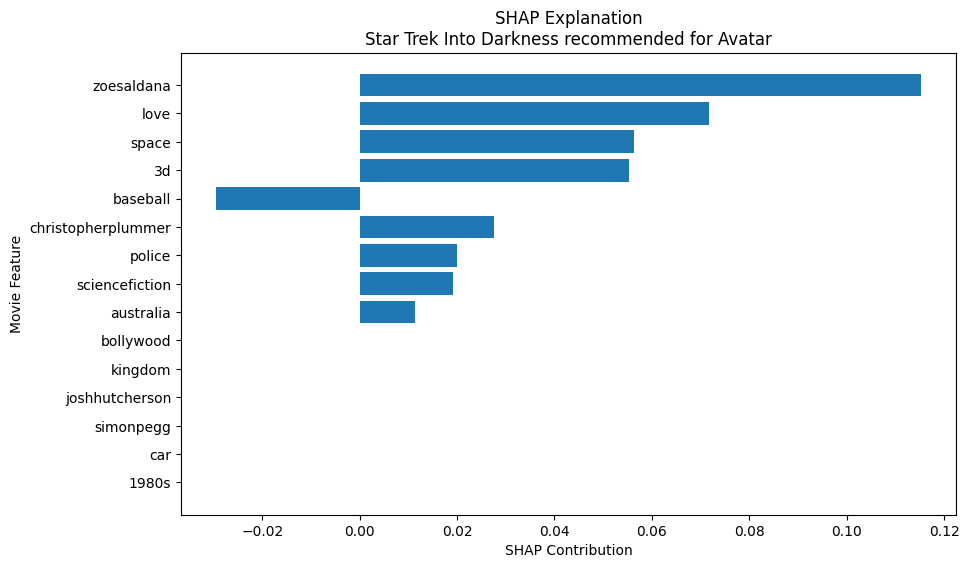

In [51]:
# Get the 15 most important features
important_indices = np.argsort(
    np.abs(shap_values_array)
)[-15:]

important_indices = important_indices[::-1]

important_features = [
    xai_feature_names[i]
    for i in important_indices
]

important_values = [
    shap_values_array[i]
    for i in important_indices
]

plt.figure(figsize=(10, 6))

plt.barh(
    important_features,
    important_values
)

plt.xlabel("SHAP Contribution")
plt.ylabel("Movie Feature")

plt.title(
    f"SHAP Explanation\n"
    f"{recommended_movie} recommended for {selected_movie}"
)

plt.gca().invert_yaxis()

plt.show()

In [52]:
from lime.lime_tabular import LimeTabularExplainer

In [53]:
lime_explainer = LimeTabularExplainer(
    xai_matrix,
    feature_names=xai_feature_names,
    mode="regression",
    discretize_continuous=False,
    random_state=42
)

print("LIME explainer created!")

LIME explainer created!


In [54]:
lime_exp = lime_explainer.explain_instance(
    recommended_vector,
    lambda X: movie_similarity_prediction(
        X,
        target_vector
    ),
    num_features=15,
    num_samples=500
)

print("LIME explanation generated!")

LIME explanation generated!


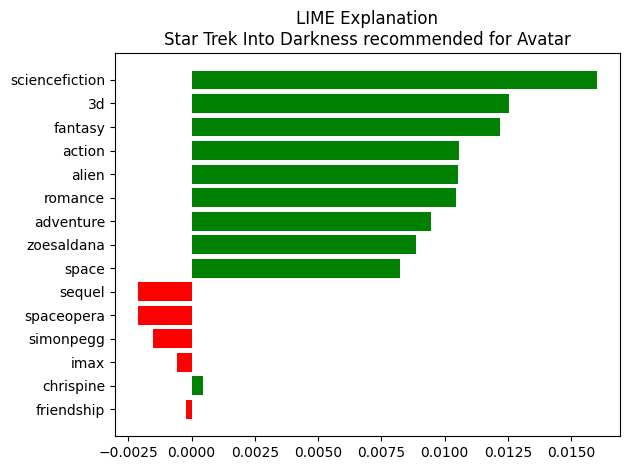

In [55]:
lime_exp.as_pyplot_figure()

plt.title(
    f"LIME Explanation\n"
    f"{recommended_movie} recommended for {selected_movie}"
)

plt.tight_layout()
plt.show()

In [56]:
print(
    f"\nLIME Explanation: "
    f"{recommended_movie} for {selected_movie}\n"
)

for feature, weight in lime_exp.as_list():
    print(f"{feature}: {weight:.4f}")


LIME Explanation: Star Trek Into Darkness for Avatar

sciencefiction: 0.0160
3d: 0.0125
fantasy: 0.0122
action: 0.0106
alien: 0.0105
romance: 0.0105
adventure: 0.0095
zoesaldana: 0.0089
space: 0.0082
sequel: -0.0021
spaceopera: -0.0021
simonpegg: -0.0015
imax: -0.0006
chrispine: 0.0004
friendship: -0.0002


In [57]:
def explainable_movie_recommender(movie_name, num_recommendations=5):

    # Check movie
    if movie_name not in movie_indices:
        print("❌ Movie not found.")
        return

    # Get recommendations
    recommendations = get_recommendations(
        movie_name,
        num_recommendations
    )

    print("=" * 70)
    print("🎬 EXPLAINABLE MOVIE RECOMMENDATION SYSTEM")
    print("=" * 70)

    print(f"\nSelected Movie: {movie_name}")

    print("\n📽️ Recommended Movies:")
    display(recommendations)

    # Select top recommendation
    recommended_movie = recommendations.iloc[0]["Recommended Movie"]

    selected_index = movie_indices[movie_name]
    recommended_index = movie_indices[recommended_movie]

    target_vector = xai_matrix[selected_index]
    recommended_vector = xai_matrix[recommended_index]

    print("\n" + "=" * 70)
    print("🔍 EXPLANATION FOR TOP RECOMMENDATION")
    print("=" * 70)

    print(f"\nSelected movie: {movie_name}")
    print(f"Recommended movie: {recommended_movie}")

    # -------------------------
    # SHAP
    # -------------------------

    background = xai_matrix[
        np.random.choice(
            xai_matrix.shape[0],
            30,
            replace=False
        )
    ]

    shap_explainer = shap.KernelExplainer(
        lambda X: movie_similarity_prediction(
            X,
            target_vector
        ),
        background
    )

    shap_values = shap_explainer.shap_values(
        recommended_vector.reshape(1, -1),
        nsamples=100
    )

    shap_values_array = np.array(shap_values)

    if shap_values_array.ndim == 3:
        shap_values_array = shap_values_array[0, :, 0]

    elif shap_values_array.ndim == 2:
        shap_values_array = shap_values_array[0]

    # Top SHAP features
    important_indices = np.argsort(
        np.abs(shap_values_array)
    )[-10:][::-1]

    important_features = [
        xai_feature_names[i]
        for i in important_indices
    ]

    important_values = [
        shap_values_array[i]
        for i in important_indices
    ]

    print("\n📊 SHAP Explanation")

    plt.figure(figsize=(10, 5))

    plt.barh(
        important_features,
        important_values
    )

    plt.xlabel("SHAP Contribution")
    plt.ylabel("Movie Feature")

    plt.title(
        f"SHAP: Why '{recommended_movie}' "
        f"was recommended for '{movie_name}'"
    )

    plt.gca().invert_yaxis()
    plt.show()

    # -------------------------
    # LIME
    # -------------------------

    lime_explainer = LimeTabularExplainer(
        xai_matrix,
        feature_names=xai_feature_names,
        mode="regression",
        discretize_continuous=False,
        random_state=42
    )

    lime_exp = lime_explainer.explain_instance(
        recommended_vector,
        lambda X: movie_similarity_prediction(
            X,
            target_vector
        ),
        num_features=10,
        num_samples=500
    )

    print("\n📊 LIME Explanation")

    lime_exp.as_pyplot_figure()

    plt.title(
        f"LIME: Why '{recommended_movie}' "
        f"was recommended for '{movie_name}'"
    )

    plt.tight_layout()
    plt.show()

    print("\n" + "=" * 70)
    print("✅ XAI ANALYSIS COMPLETED")
    print("=" * 70)


🎬 EXPLAINABLE MOVIE RECOMMENDATION SYSTEM

Selected Movie: Avatar

📽️ Recommended Movies:


,Recommended Movie,Similarity Score
0,Star Trek Into Darkness,0.2426
1,Aliens,0.2408
2,Cargo,0.2001
3,Alien³,0.1734
4,A Monster in Paris,0.1707



🔍 EXPLANATION FOR TOP RECOMMENDATION

Selected movie: Avatar
Recommended movie: Star Trek Into Darkness


  0%|          | 0/1 [00:00<?, ?it/s]


📊 SHAP Explanation


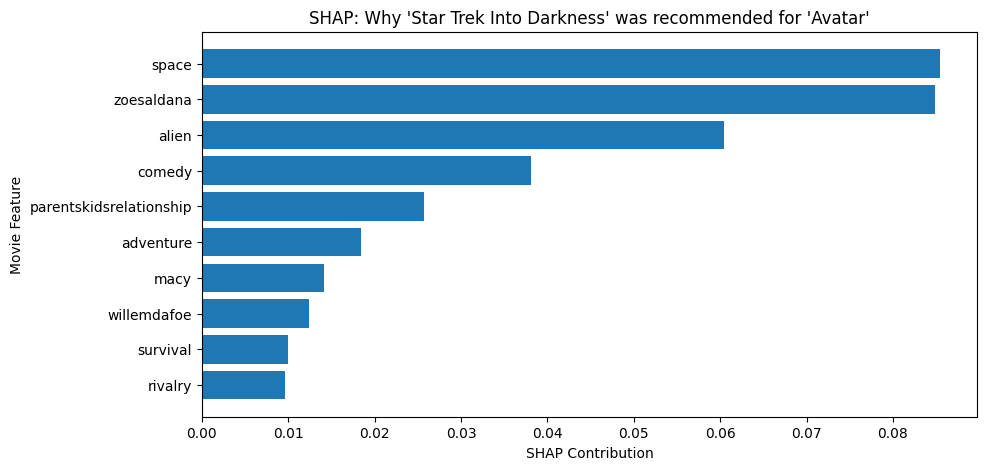


📊 LIME Explanation


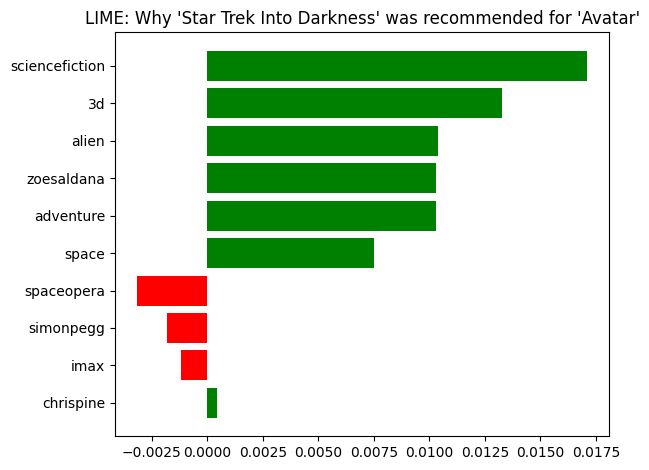


✅ XAI ANALYSIS COMPLETED


In [58]:
explainable_movie_recommender("Avatar")


🎬 EXPLAINABLE MOVIE RECOMMENDATION SYSTEM

Selected Movie: The Dark Knight

📽️ Recommended Movies:


,Recommended Movie,Similarity Score
0,Batman Begins,0.4761
1,The Dark Knight Rises,0.4549
2,Batman Returns,0.3269
3,Batman v Superman: Dawn of Justice,0.3022
4,Batman,0.2711



🔍 EXPLANATION FOR TOP RECOMMENDATION

Selected movie: The Dark Knight
Recommended movie: Batman Begins


  0%|          | 0/1 [00:00<?, ?it/s]


📊 SHAP Explanation


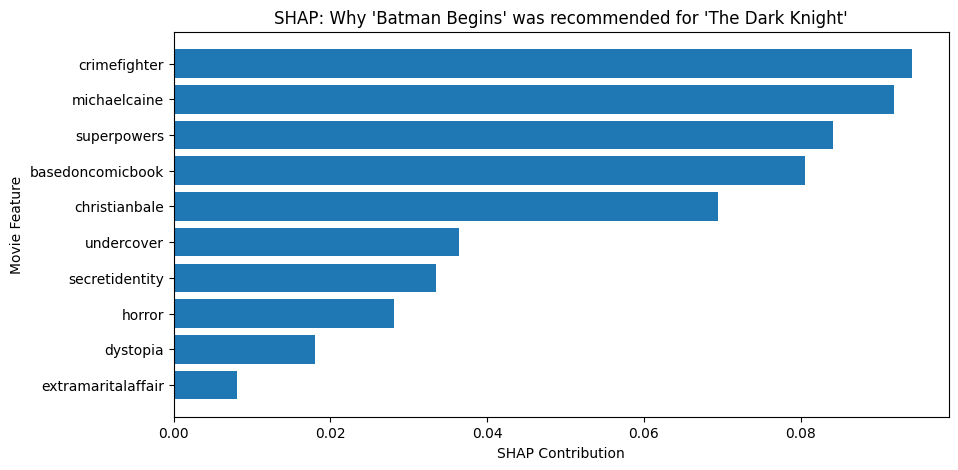


📊 LIME Explanation


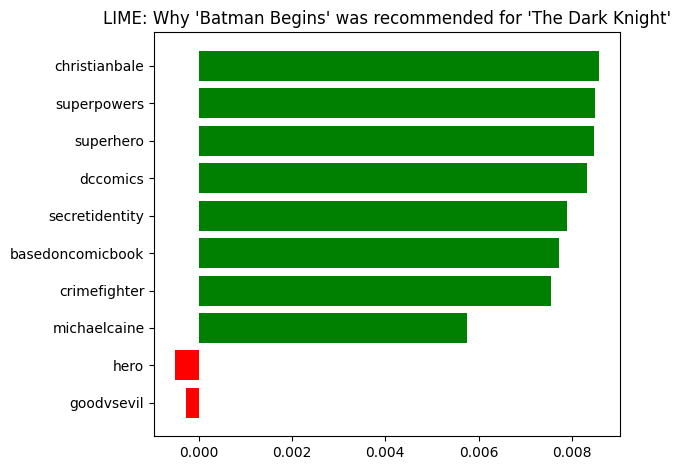


✅ XAI ANALYSIS COMPLETED


In [59]:
explainable_movie_recommender("The Dark Knight")